<a href="https://colab.research.google.com/github/lazarosgogos/ML-exercises/blob/main/ML_Project_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# -- Feature Importance, Dimensionality Reduction, KNN --

## Import libraries

In [13]:
from tensorflow.keras.datasets import mnist
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

## Q1 - Load dataset

In [14]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

## Q2 - A plot for each number

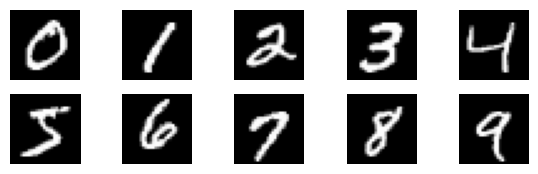

In [15]:
samples = []
for n in range(10):
  idx = np.argmax(y_train == n)#[0][0]
  samples.append(x_train[idx])
  # print(idx, n, y_train[idx])
# samples
plt.figure(1, figsize=(7,2))
for i in range(2):
  for j in range(5):
    pos = i*5 + j
    plt.subplot(2,5,pos+1)
    plt.imshow(samples[pos], cmap='grey')
    plt.axis('off')

## Q4 - What is the size of each image? Are all pixels equally significant?

The size of each image is 28x28 pixels. Each one of these pixels has a value in the range [0,255], representing its lightness value (0 being black, 255 white). No pixel value is inherently more significant than any other, as both black and white pixels convey the contrast pattern that eventually is what indicates which digit the image represents.

## Q4 - Convert the (x_train, x_test) matrices into vectors

In [16]:
size_train, size_test = len(x_train), len(x_test)
x_train_flat, x_test_flat = x_train.reshape(size_train, -1), x_test.reshape(size_test, -1)

## Q5 - Try out different values of k for KNN classification

In [17]:
knn = KNeighborsClassifier(n)
knn.fit(x_train_flat, y_train)
preds = knn.predict(x_test_flat)
accu_train_ = accuracy_score(y_test, preds)
accu_train_

0.9659

In [ ]:
Ns = [5, 15, 51, np.sqrt(len(x_train))]
accu_train = []
accu_test = []
for n in Ns:
  knn = KNeighborsClassifier(n)
  knn.fit(x_train_flat, y_train)
  train_preds = knn.predict(x_train_flat)
  test_preds = knn.predict(x_test_flat)
  accu_train.append(accuracy_score(y_train, train_preds))
  accu_test.append(accuracy_score(y_test, test_preds))

In [ ]:
plt.figure(2,figsize=(10,10))
plt.plot(Ns, accu_train)
plt.plot(Ns, accu_test)